<a href="https://colab.research.google.com/github/RASIUT/ML/blob/main/Classification/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Logistic Regression

##Importing Libraries

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Import Datasets

In [13]:
df = pd.read_csv("/content/Social_Network_Ads.csv")
X = df.iloc[:, 2:-1].values
y = df.iloc[:, -1].values

## Check for Missing Data

### Check for Missing Data

In [14]:
pd.isna(X).sum()

np.int64(0)

###No missing data found otherwise

In [15]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values = np.nan, strategy = 'most_frequent')
imputer.fit(X[:, 1:4])
X[:, 1:4] = imputer.transform(X[:, 1:4])

##Train and Test splits

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [17]:
pd.DataFrame(X_train).head()

,0,1
0,44,39000
1,32,120000
2,38,50000
3,32,135000
4,52,21000


##Feature Scaling

In [18]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Training the logistic regression model on the training set

In [19]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train, y_train)

LogisticRegression(random_state=0)

##Predicting a new result

In [20]:
classifier.predict(sc.transform([[30, 87000]]))

array([0])

##Predicting the test set results

In [38]:
y_pred = classifier.predict(X_test)

#Reshape the row y_pred & y_test row vector to column vectors
y_pred_col_vector = y_pred.reshape(len(y_pred), 1)
y_test_col_vector = y_test.reshape(len(y_test), 1)

#concatenate and paramenter 1 at last means concatenate along with axis = 1
np.concatenate((y_pred_col_vector, y_test_col_vector), axis = 1)

array([[0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 1],
       [0, 0],
       [0, 0],
       [0, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 1],
       [0, 0],
       [1, 1],
       [0,

## Making a confusion matrix

In [39]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[65  3]
 [ 8 24]]


###Heatmap

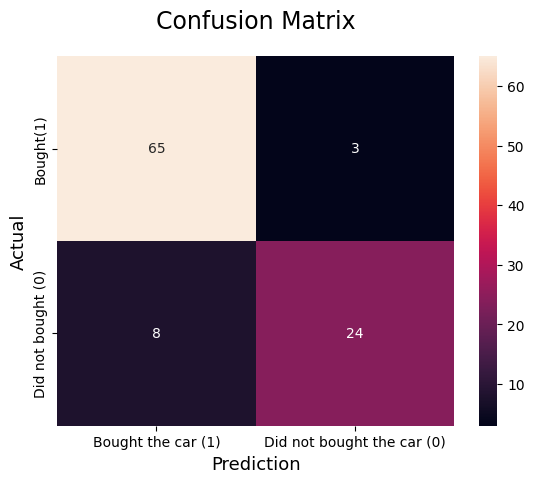

In [60]:
import seaborn as sns
sns.heatmap(cm, annot=True, xticklabels=['Bought the car (1)', 'Did not bought the car (0)'], yticklabels=['Bought(1)', 'Did not bought (0)'])

plt.title('Confusion Matrix', fontsize=17, pad=20)

plt.ylabel('Actual', fontsize=13)
plt.xlabel('Prediction', fontsize=13)

plt.show()


##Accuracy score

In [41]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))

0.89
